# Step F — CO₂ constraint sensitivity analysis

**Task (Assignment 2, part f):** Using the single-node model from Step C (Denmark with
battery storage), investigate how the optimal capacity mix changes as a function of a
global CO₂ constraint. Plot the generation mix as a function of the CO₂ cap. Compare
the resulting shadow price against Denmark's historical emissions.

**Reference emissions (Danish electricity sector):**
- 1990: ~23.5 MtCO₂ (coal-dominated, source: DEA Energy Statistics 2023)
- 2023: ~6.0 MtCO₂ (source: DEA Energy Statistics 2023)

**Emission factor:** 0.2 tCO₂/MWh_thermal for natural gas (IPCC 2006, Table 2.2)

**Requires in the working directory:**
- `DK_2015_merged.csv`
- `functions_to_investigate.py`


## Imports

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa
import importlib
import functions_to_investigate as fti


## Rebuild the Step C network

Step F extends the Step C model (Denmark + battery, 2024 costs) by adding a global CO₂
constraint. We rebuild it here so this notebook is self-contained. `dnk_storage` is the
baseline network used to compute unconstrained emissions.


In [16]:
# Load 2015 Danish data
dataframe_dk = pd.read_csv("DK_2015_merged.csv", index_col=0, sep=",", parse_dates=True)
demand_dk = dataframe_dk["DK_load_actual_entsoe_transparency"]
CF_wind = dataframe_dk["wind_cf_Unnamed: 1"]
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"]

# Cost table
data = {
    "capital_cost": [
        1500000/25 + 60000,   # wind:  120,000 $/MW/year
        800000/25 + 14000,    # solar:  46,000 $/MW/year
        700000/25 + 24000,    # CCGT:   52,000 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30]  # CCGT: ~63.4 $/MWh
}
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])

# Battery parameters (2024 Li-ion, same as Step C)
battery_investment_power  = 100_000  # $/MW
battery_investment_energy = 150_000  # $/MWh
battery_fom               =  12_500  # $/MW/year
battery_lifetime          =      20  # years
battery_max_hours         =       4  # h
battery_efficiency        =    0.90  # round-trip
battery_capital_cost_2024 = (battery_investment_power / battery_lifetime
                             + battery_fom
                             + (battery_investment_energy / battery_lifetime) * battery_max_hours)
print(f"Battery capital cost (2024): {battery_capital_cost_2024:.0f} $/MW/year")

# Step C network
dnk_storage = pypsa.Network()
dnk_storage.set_snapshots(dataframe_dk.index.values)
dnk_storage.add("Bus", "Denmark")
dnk_storage.add("Carrier", ["wind_combined", "solar", "CCGT", "battery"],
                color=["blue", "red", "brown", "purple"])
dnk_storage.add("Load", "dnk_demand", bus="Denmark", p_set=demand_dk.values)
dnk_storage.add("Generator", "wind_combined", bus="Denmark", carrier="wind_combined",
                capital_cost=costs.loc["wind_combined", "capital_cost"],
                marginal_cost=costs.loc["wind_combined", "marginal_cost"],
                p_max_pu=CF_wind.values, p_nom_extendable=True)
dnk_storage.add("Generator", "solar", bus="Denmark", carrier="solar",
                capital_cost=costs.loc["solar", "capital_cost"],
                marginal_cost=costs.loc["solar", "marginal_cost"],
                p_max_pu=CF_solar.values, p_nom_extendable=True)
dnk_storage.add("Generator", "CCGT", bus="Denmark", carrier="CCGT",
                capital_cost=costs.loc["CCGT", "capital_cost"],
                marginal_cost=costs.loc["CCGT", "marginal_cost"],
                efficiency=0.58, p_nom_extendable=True)
dnk_storage.add("StorageUnit", "battery", bus="Denmark", carrier="battery",
                capital_cost=battery_capital_cost_2024, marginal_cost=0,
                efficiency_store=battery_efficiency**0.5,
                efficiency_dispatch=battery_efficiency**0.5,
                max_hours=battery_max_hours,
                cyclic_state_of_charge=True, p_nom_extendable=True)
dnk_storage.optimize(solver_name="gurobi", solver_options={"output_flag": False})
print(f"Step C rebuilt — system cost: {dnk_storage.objective/1e9:.3f} B$/y")


Battery capital cost (2024): 47500 $/MW/year


Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 103.21it/s]

Set parameter Username



INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2706870


...

Reading time = 0.13 seconds


INFO:gurobipy:Reading time = 0.13 seconds


obj: 122644 rows, 52564 columns, 232108 nonzeros


INFO:gurobipy:obj: 122644 rows, 52564 columns, 232108 nonzeros


Step C rebuilt — system cost: 1.844 B$/y


## Baseline (unconstrained) emissions of the Step C model

In [17]:
# Calculate the unconstrained emissions from the Step C model (dnk_storage)
# Emissions = sum(g_CCGT,t) / efficiency * co2_emissions_carrier

ccgt_gen_total = dnk_storage.generators_t.p["CCGT"].sum()  # MWh
ccgt_efficiency = dnk_storage.generators.loc["CCGT", "efficiency"]
co2_factor = 0.2  # tCO2/MWh_thermal (IPCC 2006)

baseline_emissions = ccgt_gen_total / ccgt_efficiency * co2_factor  # tonnes
baseline_emissions_mt = baseline_emissions / 1e6  # MtCO2

print(f"--- Step F: Baseline (unconstrained) emissions ---")
print(f"CCGT generation:     {ccgt_gen_total/1e6:.2f} TWh")
print(f"CCGT efficiency:     {ccgt_efficiency:.0%}")
print(f"CO2 factor:          {co2_factor} tCO2/MWh_th (IPCC 2006)")
print(f"Total emissions:     {baseline_emissions_mt:.2f} MtCO2")
print(f"\nHistorical reference:")
print(f"  Denmark 1990:      ~23.5 MtCO2 (electricity sector, DEA)")
print(f"  Denmark 2023:      ~6.0 MtCO2  (electricity sector, DEA)")


--- Step F: Baseline (unconstrained) emissions ---
CCGT generation:     10.09 TWh
CCGT efficiency:     58%
CO2 factor:          0.2 tCO2/MWh_th (IPCC 2006)
Total emissions:     3.48 MtCO2

Historical reference:
  Denmark 1990:      ~23.5 MtCO2 (electricity sector, DEA)
  Denmark 2023:      ~6.0 MtCO2  (electricity sector, DEA)


Today Denmark emits about 6 MtCO₂. Our unconstrained model already starts at 3.48 MtCO₂ — much lower than reality.

This is because our model is simplified: it only has gas as a fossil (no coal), and has everything planned from scratch with 2020 costs (cheap solar and wind).


## Helper: rebuild the Step C network with an optional CO₂ cap

We attach a `co2_emissions` attribute to the `CCGT` carrier and add a `GlobalConstraint`
of type `primary_energy` on `co2_emissions` when a cap is provided.

PyPSA divides the carrier emission factor (per MWh thermal) by the generator efficiency
internally, so the effective cap is on $\sum_t \varepsilon_s / \eta_s \, g_{s,t}$.


In [18]:
def build_network_co2(co2_limit_t=None):
    n = pypsa.Network()
    n.set_snapshots(dataframe_dk.index.values)
    n.add("Bus", "Denmark")
    n.add("Carrier", ["wind_combined", "solar", "CCGT", "battery"],
          color=["blue", "red", "brown", "purple"],
          co2_emissions=[0, 0, co2_factor, 0])

    n.add("Load", "dnk_demand", bus="Denmark", p_set=demand_dk.values)

    n.add("Generator", "wind_combined", bus="Denmark", carrier="wind_combined",
          capital_cost=costs.loc["wind_combined", "capital_cost"],
          marginal_cost=costs.loc["wind_combined", "marginal_cost"],
          p_max_pu=CF_wind.values, p_nom_extendable=True)

    n.add("Generator", "solar", bus="Denmark", carrier="solar",
          capital_cost=costs.loc["solar", "capital_cost"],
          marginal_cost=costs.loc["solar", "marginal_cost"],
          p_max_pu=CF_solar.values, p_nom_extendable=True)

    n.add("Generator", "CCGT", bus="Denmark", carrier="CCGT",
          capital_cost=costs.loc["CCGT", "capital_cost"],
          marginal_cost=costs.loc["CCGT", "marginal_cost"],
          efficiency=0.58, p_nom_extendable=True)

    n.add("StorageUnit", "battery", bus="Denmark", carrier="battery",
          capital_cost=battery_capital_cost_2024, marginal_cost=0,
          max_hours=4,
          efficiency_store=np.sqrt(0.90), efficiency_dispatch=np.sqrt(0.90),
          cyclic_state_of_charge=True, p_nom_extendable=True)

    if co2_limit_t is not None:
        n.add("GlobalConstraint", "co2_limit",
              type="primary_energy", carrier_attribute="co2_emissions",
              sense="<=", constant=co2_limit_t)
    return n


## Define the cap levels and silence solver logs

In [19]:
# CO2 cap sweep: from unconstrained (np.inf) down to 0, in 15 evenly-spaced steps
# between 0 and the baseline
co2_limits_mt = np.concatenate([[np.inf], np.linspace(baseline_emissions_mt, 0, 15)])
co2_limits_mt = np.unique(co2_limits_mt)[::-1]   # descending (loose → tight)
print(f"Sweep over {len(co2_limits_mt)} CO2 cap levels, from unconstrained to 0.")


Sweep over 16 CO2 cap levels, from unconstrained to 0.


In [20]:
# Silence solver logs for the sweep
import logging, warnings
logging.getLogger("linopy").setLevel(logging.ERROR)
logging.getLogger("pypsa").setLevel(logging.ERROR)
logging.getLogger("pypsa.consistency").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=FutureWarning)


## Run the sweep

In [21]:
# Run the sweep and store the solved networks
f_results = {}

for co2_mt in co2_limits_mt:
    co2_t = co2_mt * 1e6 if np.isfinite(co2_mt) else None
    n = build_network_co2(co2_limit_t=co2_t)
    n.optimize(solver_name="gurobi",
               solver_options={"output_flag": False},
            
               progress=False)
    f_results[co2_mt] = n
    print(f"  CO2 cap {co2_mt:6.2f} MtCO2 → cost {n.objective/1e9:.3f} B$/y")


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2706870


INFO:gurobipy:Set parameter LicenseID to value 2706870


Academic license - for non-commercial use only - expires 2026-09-10


...

Reading time = 0.12 seconds


INFO:gurobipy:Reading time = 0.12 seconds


obj: 122645 rows, 52564 columns, 240868 nonzeros


INFO:gurobipy:obj: 122645 rows, 52564 columns, 240868 nonzeros


  CO2 cap   0.00 MtCO2 → cost 6.013 B$/y


## Extract results into a summary DataFrame

In [22]:
def extract_result(co2_mt, n):
    has_constraint = np.isfinite(co2_mt) and "co2_limit" in n.global_constraints.index
    return {
        "co2_limit_mt":     co2_mt if np.isfinite(co2_mt) else baseline_emissions_mt * 1.1,
        "co2_actual_mt":    n.generators_t.p["CCGT"].sum() / 0.58 * co2_factor / 1e6,
        "co2_shadow_price": -n.global_constraints.loc["co2_limit", "mu"] if has_constraint else 0.0,
        "system_cost":      n.objective / 1e9,
        "wind_cap":         n.generators.p_nom_opt["wind_combined"] / 1e3,
        "solar_cap":        n.generators.p_nom_opt["solar"] / 1e3,
        "ccgt_cap":         n.generators.p_nom_opt["CCGT"] / 1e3,
        "battery_cap":      n.storage_units.p_nom_opt["battery"] / 1e3,
        "wind_gen":         n.generators_t.p["wind_combined"].sum() / 1e6,
        "solar_gen":        n.generators_t.p["solar"].sum() / 1e6,
        "ccgt_gen":         n.generators_t.p["CCGT"].sum() / 1e6,
    }

df_f = pd.DataFrame([extract_result(mt, n) for mt, n in f_results.items()])
df_f.round(3)


,co2_limit_mt,co2_actual_mt,co2_shadow_price,system_cost,wind_cap,solar_cap,ccgt_cap,battery_cap,wind_gen,solar_gen,ccgt_gen
0,3.827,3.479,0.000,1.844,6.038,4.489,4.417,0.921,18.039,4.743,10.090
1,3.479,3.479,0.324,1.844,6.038,4.489,4.417,0.921,18.044,4.743,10.090
2,3.231,3.231,19.459,1.846,6.326,4.790,4.386,0.945,18.449,5.061,9.370
3,2.982,2.982,43.796,1.854,6.628,5.167,4.349,0.975,18.785,5.454,8.649
4,2.734,2.734,62.371,1.867,6.797,5.828,4.223,1.287,18.847,6.139,7.928
5,2.485,2.485,92.759,1.885,7.012,6.469,4.104,1.600,18.979,6.760,7.207
6,2.237,2.237,126.735,1.912,7.566,6.542,4.072,1.701,19.626,6.841,6.487
7,1.988,1.988,168.310,1.949,7.906,7.019,3.995,2.194,19.950,7.270,5.766
8,1.740,1.740,210.964,1.997,8.163,7.710,3.886,2.957,20.116,7.880,5.045
9,1.491,1.491,286.740,2.059,8.376,8.698,3.756,3.876,20.039,8.737,4.324


CO2 Shadow Price is the system cost to reduce 1 more ton of CO2 at that particular point.


At 2 MtCO₂: $168/tCO₂ — almost reasonable

At 1 MtCO₂: $510/tCO₂ — expensive

At 0.5 MtCO₂: $1,232/tCO₂ — very expensive

At 0 MtCO₂: $36,116/tCO₂ — crazy


## Plots

In [23]:
importlib.reload(fti)


<module 'functions_to_investigate' from '/Users/kenzomaetanimachholm/Desktop/DTU/Masters - Semester 2/Integrated Energy/Integrated-Energy-Grids-A1G21/functions_to_investigate.py'>

<Axes: title={'center': 'Generation Mix vs CO₂ Emissions'}, xlabel='Actual CO₂ Emissions [MtCO₂/year]', ylabel='Annual Generation [TWh]'>

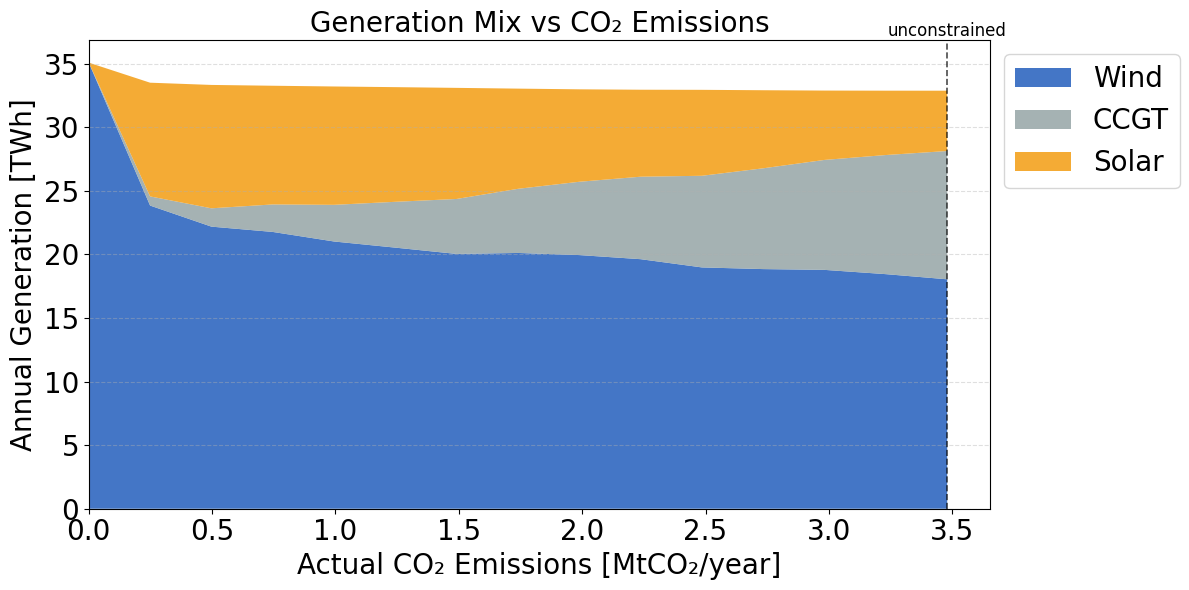

In [24]:
fti.plot_generation_vs_co2(df_f, baseline_emissions_mt)


<Axes: title={'center': 'Optimal Capacity Mix vs CO₂ Emissions'}, xlabel='Actual CO₂ Emissions [MtCO₂/year]', ylabel='Installed Capacity [GW]'>

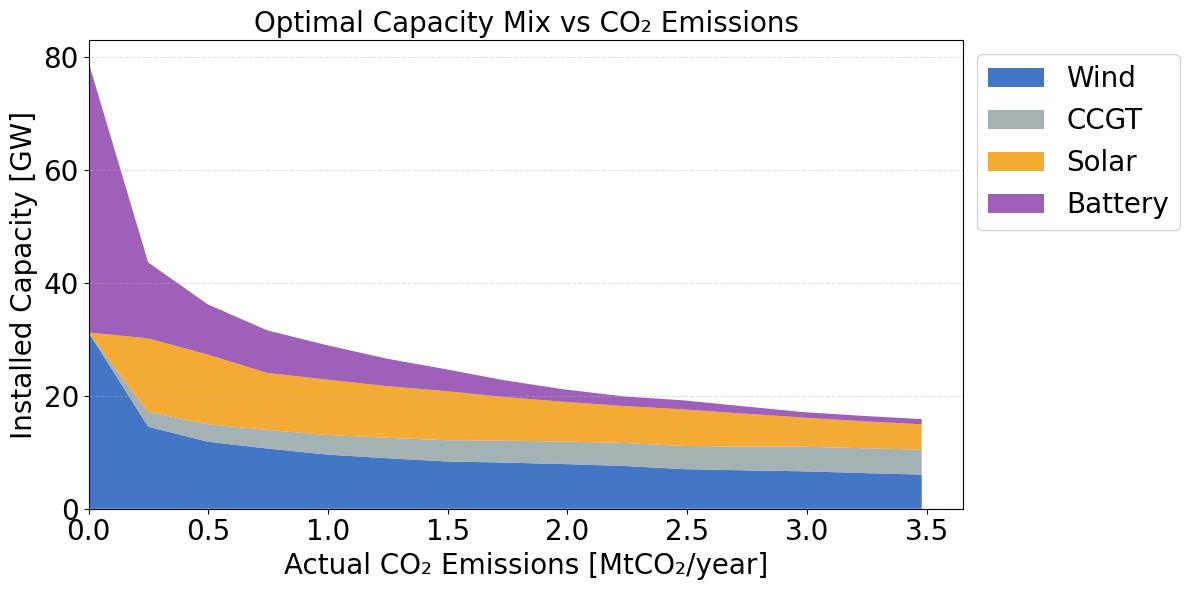

In [25]:
fti.plot_capacity_vs_co2(df_f, baseline_emissions_mt)


(<Axes: title={'center': 'System Cost and CO₂ Price vs Emissions'}, xlabel='CO₂ Emissions [MtCO₂/year]', ylabel='System Cost [B$/year]'>,
 <Axes: ylabel='CO₂ Shadow Price [$/tCO₂]'>)

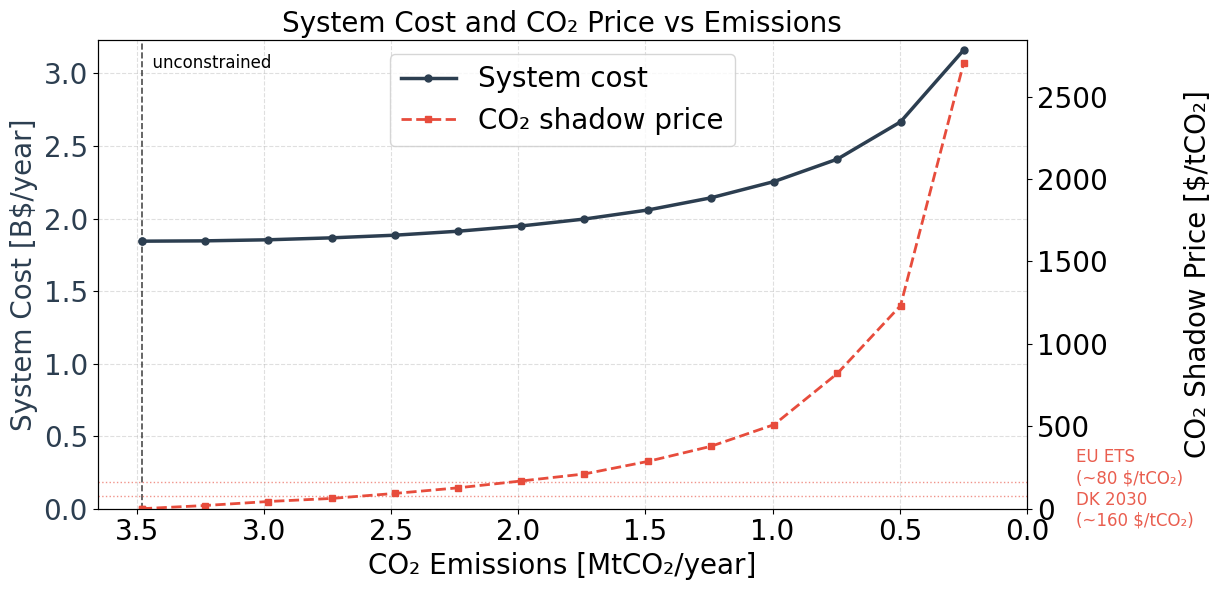

In [26]:
fti.plot_cost_and_price_vs_co2(df_f, baseline_emissions_mt)
